# African Inflation Prediction Model
## Predicting inflation rates using African economic crisis data

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

In [17]:
# Load dataset
df = pd.read_csv('african_crises (1).csv')
print(f"Dataset shape: {df.shape}")
print("\nColumns:", df.columns.tolist())
df.head()

Dataset shape: (1059, 14)

Columns: ['case', 'cc3', 'country', 'year', 'systemic_crisis', 'exch_usd', 'domestic_debt_in_default', 'sovereign_external_debt_default', 'gdp_weighted_default', 'inflation_annual_cpi', 'independence', 'currency_crises', 'inflation_crises', 'banking_crisis']


,case,cc3,country,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis
0,1,DZA,Algeria,1870,1,0.052264,0,0,0.0,3.441456,0,0,0,crisis
1,1,DZA,Algeria,1871,0,0.052798,0,0,0.0,14.149140,0,0,0,no_crisis
2,1,DZA,Algeria,1872,0,0.052274,0,0,0.0,-3.718593,0,0,0,no_crisis
3,1,DZA,Algeria,1873,0,0.051680,0,0,0.0,11.203897,0,0,0,no_crisis
4,1,DZA,Algeria,1874,0,0.051308,0,0,0.0,-3.848561,0,0,0,no_crisis


In [18]:
# Data exploration
print("Dataset Info:")
df.info()
print("\nMissing values:")
print(df.isnull().sum())
print("\nStatistical summary:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   case                             1059 non-null   int64  
 1   cc3                              1059 non-null   object 
 2   country                          1059 non-null   object 
 3   year                             1059 non-null   int64  
 4   systemic_crisis                  1059 non-null   int64  
 5   exch_usd                         1059 non-null   float64
 6   domestic_debt_in_default         1059 non-null   int64  
 7   sovereign_external_debt_default  1059 non-null   int64  
 8   gdp_weighted_default             1059 non-null   float64
 9   inflation_annual_cpi             1059 non-null   float64
 10  independence                     1059 non-null   int64  
 11  currency_crises                  1059 non-null   int64  
 12  inflat

,case,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises
count,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1.059000e+03,1059.000000,1059.000000,1059.000000
mean,35.613787,1967.767705,0.077432,43.140831,0.039660,0.152975,0.006402,2.084889e+04,0.776204,0.132200,0.129367
std,23.692402,33.530632,0.267401,111.475380,0.195251,0.360133,0.043572,6.757274e+05,0.416984,0.349847,0.335765
min,1.000000,1860.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.850214e+01,0.000000,0.000000,0.000000
25%,15.000000,1951.000000,0.000000,0.195350,0.000000,0.000000,0.000000,2.086162e+00,1.000000,0.000000,0.000000
50%,38.000000,1973.000000,0.000000,0.868400,0.000000,0.000000,0.000000,5.762330e+00,1.000000,0.000000,0.000000
75%,56.000000,1994.000000,0.000000,8.462750,0.000000,0.000000,0.000000,1.164405e+01,1.000000,0.000000,0.000000
max,70.000000,2014.000000,1.000000,744.306139,1.000000,1.000000,0.400000,2.198970e+07,1.000000,2.000000,1.000000


In [19]:
# Feature engineering - CATEGORICAL TO NUMERIC CONVERSION
print("=== FEATURE ENGINEERING: CATEGORICAL TO NUMERIC CONVERSION ===")

# Remove rows with missing inflation data
df_clean = df.dropna(subset=['inflation_annual_cpi'])
print(f"After removing missing inflation data: {df_clean.shape}")

# Convert categorical variables to numeric using pd.get_dummies
print("\n1. Converting 'country' to numeric using pd.get_dummies:")
print(f"Original countries: {df_clean['country'].unique()}")
country_dummies = pd.get_dummies(df_clean['country'], prefix='country')
print(f"Created {country_dummies.shape[1]} country dummy variables")

print("\n2. Converting 'banking_crisis' to numeric:")
print(f"Original banking_crisis values: {df_clean['banking_crisis'].unique()}")
df_clean['banking_crisis'] = df_clean['banking_crisis'].map({'crisis': 1, 'no_crisis': 0})
df_clean['banking_crisis'] = df_clean['banking_crisis'].fillna(0)
print(f"Converted to: {df_clean['banking_crisis'].unique()}")

# Combine original data with country dummies
df_clean = pd.concat([df_clean, country_dummies], axis=1)

# Select relevant features for prediction
base_features = ['year', 'systemic_crisis', 'exch_usd', 'domestic_debt_in_default', 
                'sovereign_external_debt_default', 'gdp_weighted_default', 
                'inflation_crises', 'banking_crisis']
country_features = list(country_dummies.columns)
features = base_features + country_features

print(f"\nTotal features selected: {len(features)}")
print(f"Base features: {len(base_features)}, Country features: {len(country_features)}")

# Handle missing values
for col in features:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f"\nFinal clean dataset shape: {df_clean.shape}")
print("Feature engineering completed successfully!")

=== FEATURE ENGINEERING: CATEGORICAL TO NUMERIC CONVERSION ===
After removing missing inflation data: (1059, 14)

1. Converting 'country' to numeric using pd.get_dummies:
Original countries: ['Algeria' 'Angola' 'Central African Republic' 'Ivory Coast' 'Egypt'
 'Kenya' 'Mauritius' 'Morocco' 'Nigeria' 'South Africa' 'Tunisia' 'Zambia'
 'Zimbabwe']
Created 13 country dummy variables

2. Converting 'banking_crisis' to numeric:
Original banking_crisis values: ['crisis' 'no_crisis']
Converted to: [1 0]

Total features selected: 21
Base features: 8, Country features: 13

Final clean dataset shape: (1059, 27)
Feature engineering completed successfully!


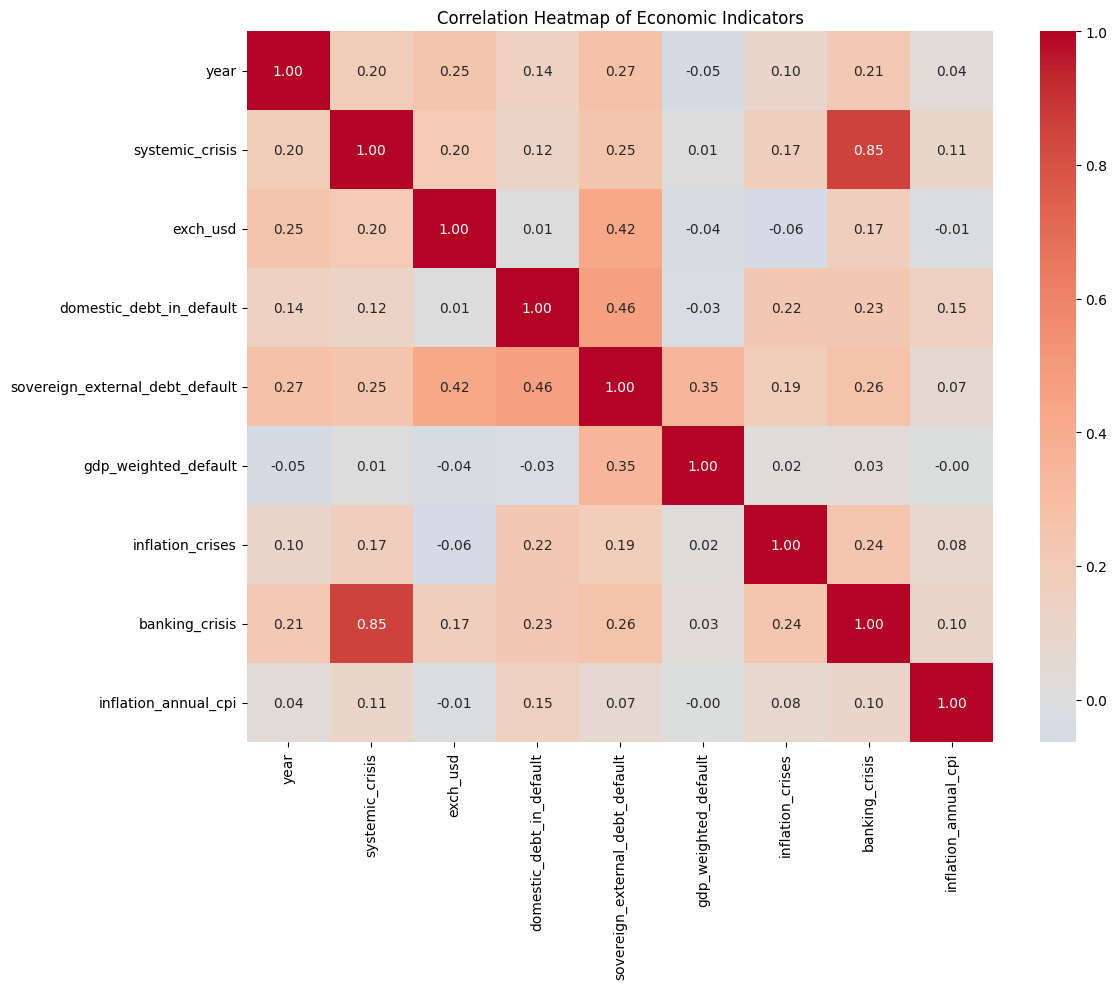

✓ Correlation Heatmap completed


In [20]:
# Visualization 1: Correlation heatmap (MANDATORY)
plt.figure(figsize=(12, 10))
correlation_features = ['year', 'systemic_crisis', 'exch_usd', 'domestic_debt_in_default', 
                       'sovereign_external_debt_default', 'gdp_weighted_default', 
                       'inflation_crises', 'banking_crisis', 'inflation_annual_cpi']
correlation_data = df_clean[correlation_features].corr()
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Economic Indicators')
plt.tight_layout()
plt.savefig('inflation_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Correlation Heatmap completed")

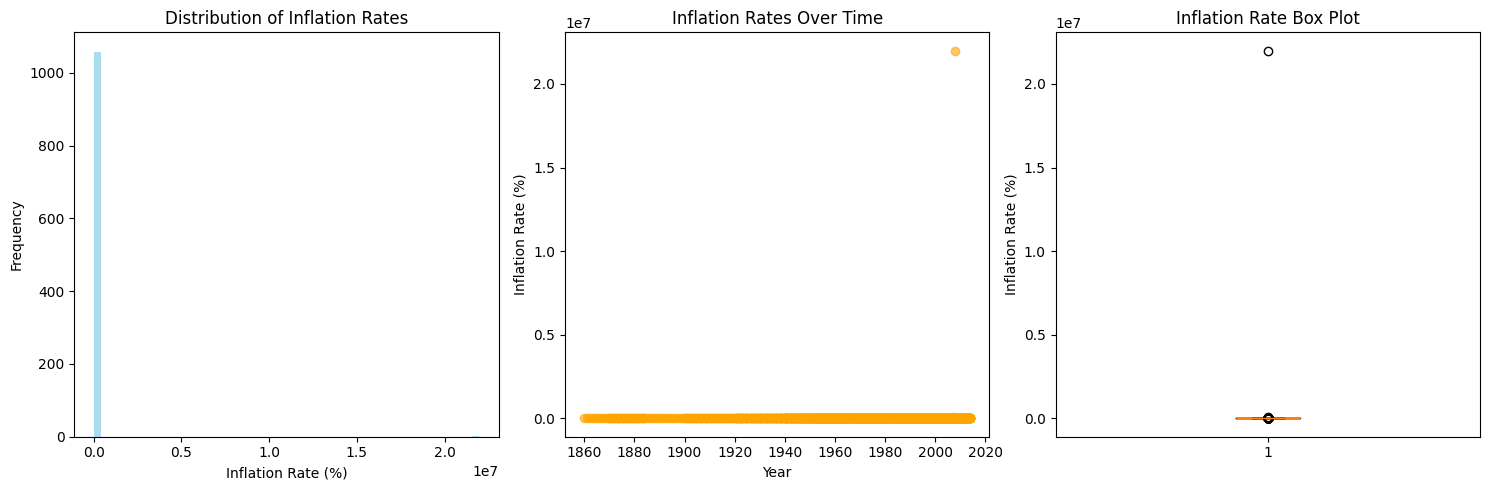

✓ Target Distribution plots completed


In [21]:
# Visualization 2: Target Distribution (MANDATORY)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(df_clean['inflation_annual_cpi'], bins=50, alpha=0.7, color='skyblue')
plt.title('Distribution of Inflation Rates')
plt.xlabel('Inflation Rate (%)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.scatter(df_clean['year'], df_clean['inflation_annual_cpi'], alpha=0.6, color='orange')
plt.title('Inflation Rates Over Time')
plt.xlabel('Year')
plt.ylabel('Inflation Rate (%)')

plt.subplot(1, 3, 3)
plt.boxplot(df_clean['inflation_annual_cpi'])
plt.title('Inflation Rate Box Plot')
plt.ylabel('Inflation Rate (%)')

plt.tight_layout()
plt.show()
print("✓ Target Distribution plots completed")

In [22]:
# Prepare data for modeling
X = df_clean[features]
y = df_clean['inflation_annual_cpi']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

Training set shape: (847, 21)
Test set shape: (212, 21)


In [23]:
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print(f"Linear Regression - MSE: {lr_mse:.4f}, R²: {lr_r2:.4f}")

Linear Regression - MSE: 2280205463446.0776, R²: -0.0044


In [24]:
# Model 2: Decision Tree
dt_model = DecisionTreeRegressor(random_state=42, max_depth=10)
dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print(f"Decision Tree - MSE: {dt_mse:.4f}, R²: {dt_r2:.4f}")

Decision Tree - MSE: 2267151609235.5889, R²: 0.0013


In [25]:
# Model 3: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest - MSE: {rf_mse:.4f}, R²: {rf_r2:.4f}")

Random Forest - MSE: 2272154437756.1768, R²: -0.0009


In [26]:
# Compare models and select best
models = {
    'Linear Regression': (lr_model, lr_mse, lr_pred),
    'Decision Tree': (dt_model, dt_mse, dt_pred),
    'Random Forest': (rf_model, rf_mse, rf_pred)
}

best_model_name = min(models.keys(), key=lambda k: models[k][1])
best_model, best_mse, best_pred = models[best_model_name]

print(f"\nBest Model: {best_model_name} with MSE: {best_mse:.4f}")

# Save best model and scaler
joblib.dump(best_model, 'best_inflation_model.pkl')
joblib.dump(scaler, 'inflation_scaler.pkl')
print("Models saved successfully!")


Best Model: Decision Tree with MSE: 2267151609235.5889
Models saved successfully!


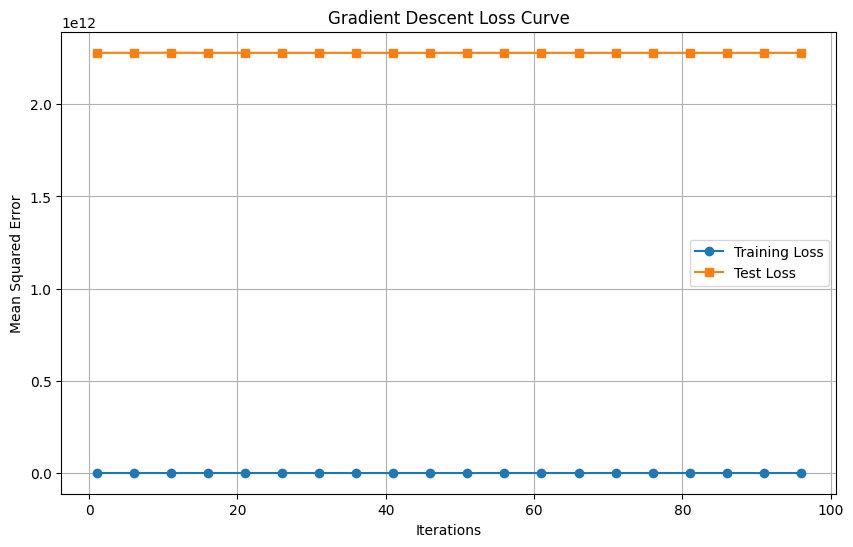

✓ Gradient Descent Loss Curve completed


In [27]:
# Gradient Descent Loss Curve (MANDATORY)
train_losses = []
test_losses = []

for i in range(1, 101, 5):
    sgd_temp = SGDRegressor(max_iter=i, random_state=42)
    sgd_temp.fit(X_train_scaled, y_train)
    
    train_pred = sgd_temp.predict(X_train_scaled)
    test_pred = sgd_temp.predict(X_test_scaled)
    
    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 101, 5), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, 101, 5), test_losses, label='Test Loss', marker='s')
plt.xlabel('Iterations')
plt.ylabel('Mean Squared Error')
plt.title('Gradient Descent Loss Curve')
plt.legend()
plt.grid(True)
plt.savefig('inflation_gd_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gradient Descent Loss Curve completed")

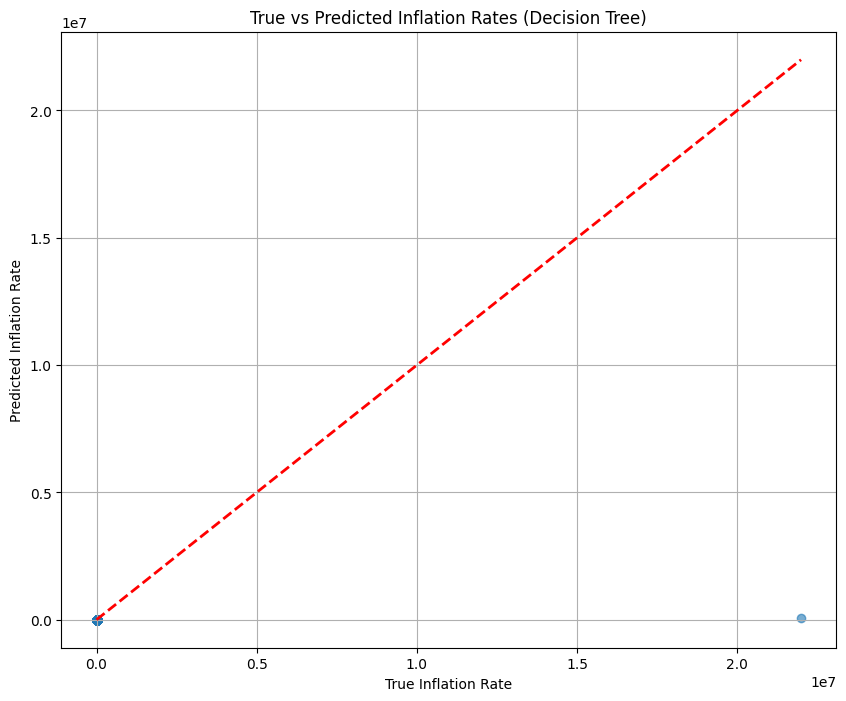

✓ True vs Predicted Scatter Plot completed


In [28]:
# True vs Predicted Scatter Plot (MANDATORY)
plt.figure(figsize=(10, 8))
plt.scatter(y_test, best_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('True Inflation Rate')
plt.ylabel('Predicted Inflation Rate')
plt.title(f'True vs Predicted Inflation Rates ({best_model_name})')
plt.grid(True)
plt.savefig('inflation_true_vs_predicted_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ True vs Predicted Scatter Plot completed")

In [29]:
# Test prediction function (MANDATORY)
def predict_inflation(year, systemic_crisis, exch_usd, domestic_debt_in_default, 
                     sovereign_external_debt_default, gdp_weighted_default, 
                     inflation_crises, banking_crisis, country='Algeria'):
    model = joblib.load('best_inflation_model.pkl')
    scaler = joblib.load('inflation_scaler.pkl')
    
    input_dict = {
        'year': year, 'systemic_crisis': systemic_crisis, 'exch_usd': exch_usd,
        'domestic_debt_in_default': domestic_debt_in_default,
        'sovereign_external_debt_default': sovereign_external_debt_default,
        'gdp_weighted_default': gdp_weighted_default,
        'inflation_crises': inflation_crises, 'banking_crisis': banking_crisis
    }
    
    for col in country_features:
        input_dict[col] = 0
    
    country_col = f'country_{country}'
    if country_col in country_features:
        input_dict[country_col] = 1
    
    input_df = pd.DataFrame([input_dict])[features]
    input_scaled = scaler.transform(input_df)
    prediction = model.predict(input_scaled)[0]
    return prediction

# Test with sample data
print("=== TESTING PREDICTION FUNCTION ===")
test_sample = X_test.iloc[0]
test_country = df_clean.iloc[X_test.index[0]]['country']
test_values = test_sample[base_features].values
prediction = predict_inflation(*test_values, country=test_country)
actual = y_test.iloc[0]

print(f"Test Country: {test_country}")
print(f"Predicted Inflation: {prediction:.2f}%")
print(f"Actual Inflation: {actual:.2f}%")
print(f"Prediction Error: {abs(prediction - actual):.2f}%")
print("✓ Prediction function test completed")

=== TESTING PREDICTION FUNCTION ===
Test Country: Morocco
Predicted Inflation: 46.34%
Actual Inflation: 28.51%
Prediction Error: 17.84%
✓ Prediction function test completed
